# C5.4 Networks Mini Project
*By Candidate 1072086*



---



In this notebook, we examine the all-or-none model as proposed in the miniproject brief.

All-or-none models are described as follows. At time $t=0$, the system consists of a single node. At each subsequent time step, a new node is added and connected to an existing target node chosen uniformly at random. In addition, the new node attempts to connect to the neighbours of the target node: with probability $p$, it connects to all neighbours of the target node, while with probability $1-p$, it connects to none of them. This growth process is repeated recursively.

We shall explore the following aspects through numerical simulations:


1.   How the total number of links depends on $p$ and on the number of nodes $N$;
2.   The degree distribution in the sparse regime;
3.   The number of triangles and the clustering coefficient;
4.   The assortativity coefficient;
5.   The average shortest-path distance between pairs of nodes.

We shall also explore the following additional properties of the model:

6. Meow
7. Woof
8. Scrrr

For each property, we shall provide numerical evidence for the validity of the analytical expression derived in the report for that property.


*Before continuing, please run the following imports:*

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import gammaln, gamma, digamma
from mpl_toolkits.mplot3d import Axes3D
import networkx as nx

## Structural Properties of the All-Or-None Model

### Number of Links $L_N$

In our report, we obtain the following exact expressions for the expected value of links $L_N$:

\begin{equation}
     \mathbb{E}[L_N]=
    \begin{cases}
        N(H_N - 1) & \text{for } p = \frac{1}{2} \\
        \frac{N}{1-2p} + \frac{\Gamma(2p+N)}{(2p-1)\Gamma(2p+1)\Gamma(N)} &\text{for } p \neq \frac{1}{2},
    \end{cases}
\end{equation}

and the following asymptotic expressions for the expected value of links $L_N$:

\begin{equation}
    \mathbb{E}[L_N] \sim
    \begin{cases}
       \frac{N}{1-2p}& \text{for }0 \leq p < \frac{1}{2} \\
        N\log N & \text{for } p = \frac{1}{2} \\
        \frac{N^{2p}}{(2p-1)\Gamma(2p+1)} &\text{for } \frac{1}{2}<p \leq 1.
    \end{cases}
\end{equation}

We provide numerical evidence supporting these conclusions using the code below, which simulates the all-or-none model by Monte-Carlo simulations. Note that we aim to plot the expected number of edges as a function of $p$ for different values of $N$ and compare them with the expressions we obtained. Thus, we can show this as a 3D plot with 2D slices.

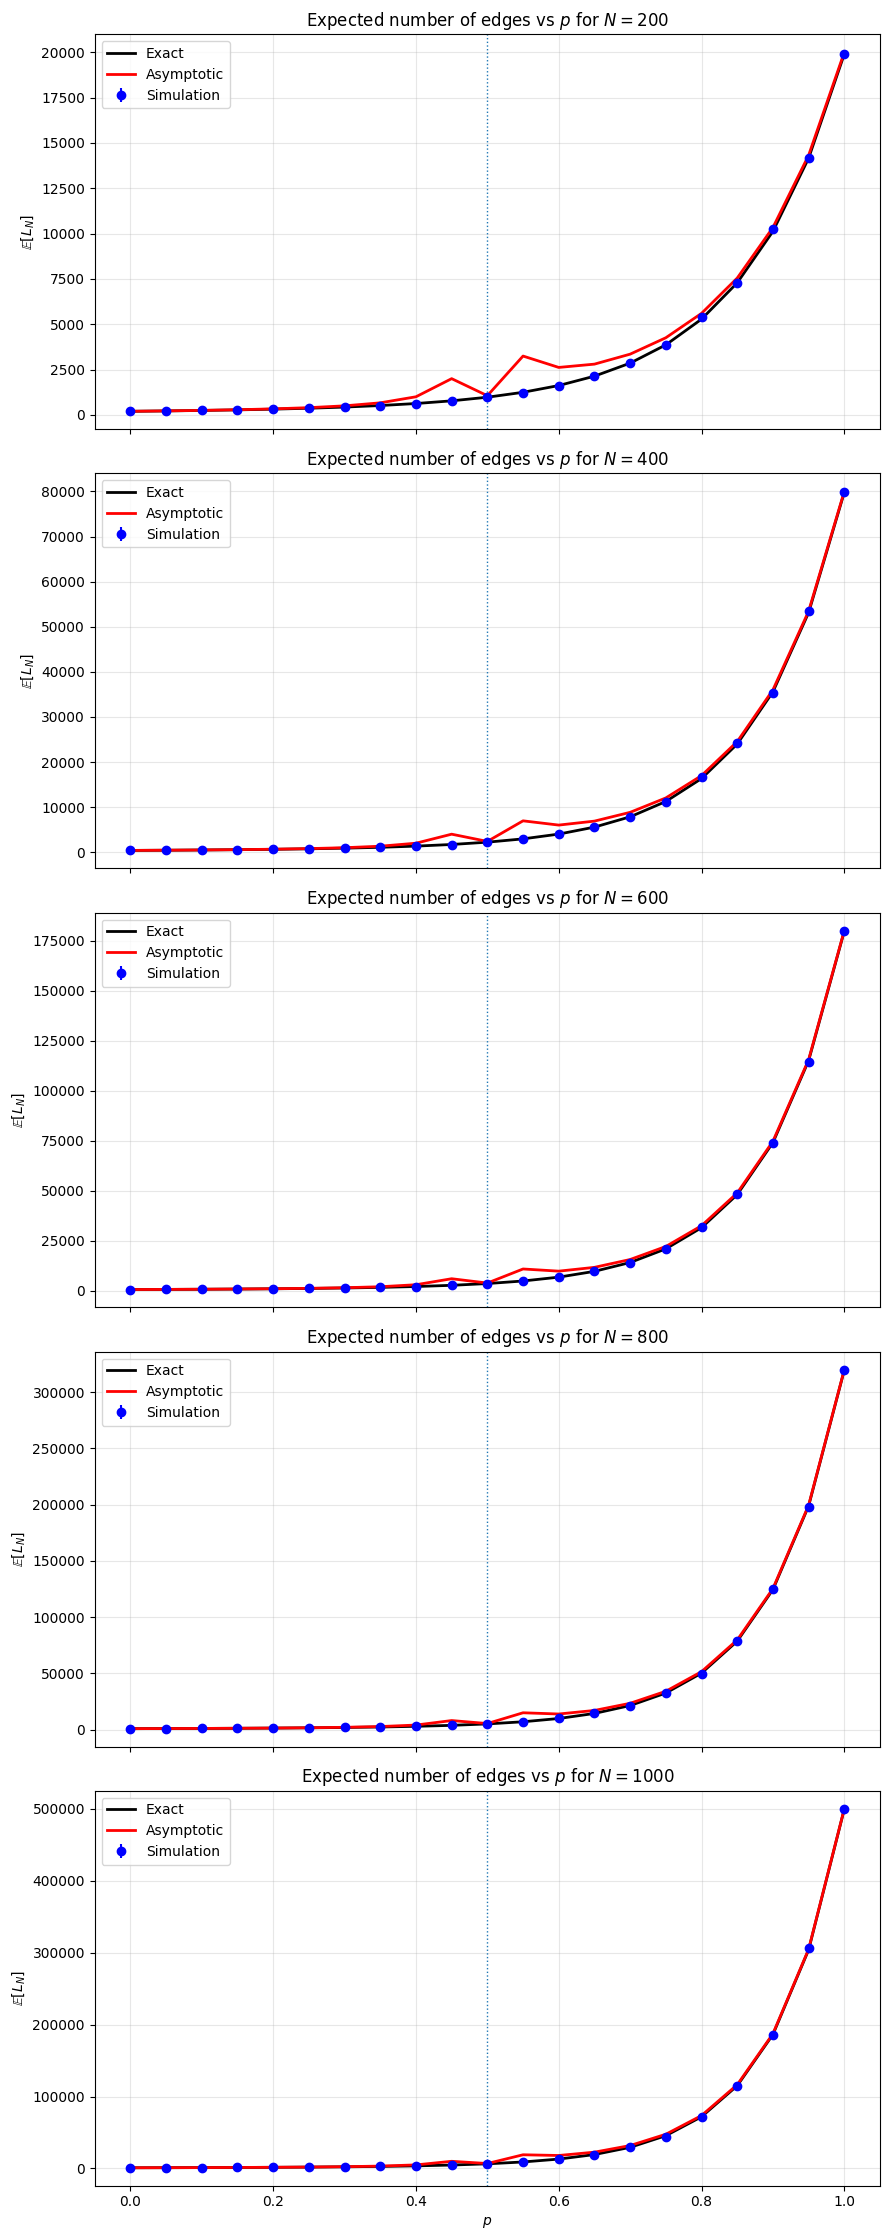

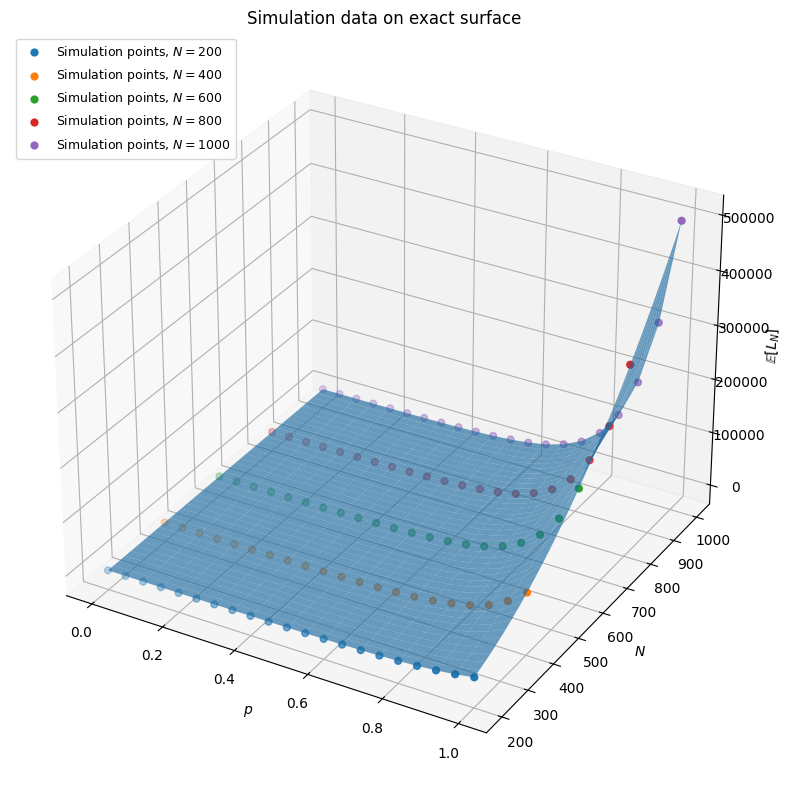

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import gammaln, gamma, digamma
from mpl_toolkits.mplot3d import Axes3D

euler_mascheroni_gamma = 0.5772156649015328606 # just an approximation of the Euler-Mascheroni constant

def harmonic_number(n): # we use fact that digamma(x+1) = - euler-mascheroni constant + H_n
  n = np.asarray(n, dtype = float)
  return digamma(n+1.0) + euler_mascheroni_gamma

def expected_edges_exact(N, p): # this gives exact expected number of edges
  N = np.asarray(N, dtype = float) # number of nodes
  p = np.asarray(p, dtype = float) # probability of copying
  N_b, p_b = np.broadcast_arrays(N, p) # makes both into arrays so we can study dependence on $p$ and $N$
  out = np.empty_like(N_b, dtype = float) # this stores exact expected number of edges, depending on $p$ and $N$
  critical = (np.abs(p_b - 0.5) == 0)
  noncritical = ~critical

  if np.any(critical): # for any p = 1/2
    out[critical] = N_b[critical] * (harmonic_number(N_b[critical]) - 1)

  if np.any(noncritical): # for any p != 1/2
    Nn = N_b[noncritical]
    pn = p_b[noncritical]
    log_ratio = (gammaln(Nn + 2.0 * pn) - gammaln(1.0 + 2.0 * pn) - gammaln(Nn))
    ratio = np.exp(log_ratio)
    out[noncritical] = (Nn / (1.0 - 2.0 * pn) - ratio / (1.0 - 2.0 * pn))

  return out

def expected_edges_asymptotic(N, p):
  N = np.asarray(N, dtype = float) # number of nodes
  p = np.asarray(p, dtype = float) # probability of copying
  N_b, p_b = np.broadcast_arrays(N, p) # makes both into arrays so we can study dependence on $p$ and $N$
  out = np.full_like(N_b, np.nan, dtype=float)
  left = (p_b < 0.5)
  right = (p_b > 0.5)
  critical = (p_b == 0.5)

  if np.any(left): # for any p < 0.5
    out[left] = N_b[left] / (1.0 - 2.0 * p_b[left])

  if np.any(right): # for any p > 0.5
    out[right] = N_b[right] ** (2.0 * p_b[right])/ ((2.0 * p_b[right] - 1.0) * gamma(1.0 + 2.0 * p_b[right]))

  if np.any(critical): # for any p = 0.5
    out[critical] = N_b[critical] * np.log(N_b[critical])

  return out

def simulate_one_run(N,p,rng):
  if N < 1:
    raise ValueError("N must be at least 1")
  if N == 1:
    return 0
  if p < 0 or p > 1:
    raise ValueError("p must be between 0 and 1")
  adjacency = [set() for _ in range(N)] # adjacency[i] is set of neighbours of node i
  edge_count = 0

  for new_node in range(1,N): # existing nodes at step t are 0, 1, ..., t-1
    target_node = rng.integers(new_node)  # choose target uniformly
    target_neighbours = list(adjacency[target_node]) # looks at neighbours before attaching new node
    adjacency[new_node].add(target_node) # adds target node to new node as edge
    adjacency[target_node].add(new_node) # adds new node to target node as edge
    edge_count += 1
    if rng.random() < p: # with probability p, copy all neighbours of the target
      for neighbour in target_neighbours:
        adjacency[new_node].add(neighbour)
        adjacency[neighbour].add(new_node)
        edge_count += 1

  return edge_count

def monte_carlo_expected_edges(N,p, num_runs = 1000, seed = None):
  rng = np.random.default_rng(seed) # allows for reproducibility
  samples = np.empty(num_runs, dtype = float)
  for r in range(num_runs):
    samples[r] = simulate_one_run(N,p, rng)
  mean_edges = samples.mean() # sample mean of L_N
  std_edges = samples.std(ddof=1) # sample standard deviation of L_N
  sem_edges = std_edges / np.sqrt(num_runs) # sample standard error of mean of L_N
  return mean_edges, std_edges, sem_edges

def monte_carlo_curve(N, p_values, num_runs = 1000, seed = None):
  means = np.empty_like(p_values, dtype=float)
  stds = np.empty_like(p_values, dtype=float)
  sems = np.empty_like(p_values, dtype=float)

  rng = np.random.default_rng(seed) # allows for reproducibility

  for i, p in enumerate(p_values):
    samples = np.empty(num_runs, dtype = float)
    for r in range(num_runs):
      samples[r] = simulate_one_run(N,p, rng)

    means[i] = samples.mean() # sample mean
    stds[i] = samples.std(ddof=1) # sample standard deviation
    sems[i] = stds[i] / np.sqrt(num_runs) # sample standard error of mean

  return means, stds, sems

def plot_overlay_2d(N_values, p_values, num_runs = 1000, seed=1111): # for each fixed N, we plot exact curve, asymptotic curve, and simulation mean with error bars
  fig, axes = plt.subplots(nrows=len(N_values), ncols=1, figsize=(9, 4.5 * len(N_values)),sharex=True)
  if len(N_values) == 1:
    axes = [axes]
  for ax, N in zip(axes, N_values):
    exact_curve = expected_edges_exact(N, p_values) # exact expression
    asymptotic_curve = expected_edges_asymptotic(N, p_values) # asymptotic expression
    means, stds, sems = monte_carlo_curve(N, p_values,num_runs=num_runs, seed=seed + N) #monte carlo simulations

    ax.plot(p_values, exact_curve, linewidth = 2.0, label="Exact", color="black") # plots exact curve
    ax.plot(p_values, asymptotic_curve, linewidth = 2.0, label="Asymptotic", color="red") # plots asymptotic curve
    ax.errorbar(p_values, means, yerr=sems, fmt="o", color="blue", label="Simulation") # plots simulation curve

    ax.axvline(0.5, linestyle=":", linewidth=1.0) # marks critical point p = 1/2
    ax.set_ylabel(r"$\mathbb{E}[L_N]$")
    ax.set_title(fr"Expected number of edges vs $p$ for $N={N}$")
    ax.grid(True, alpha=0.3)
    ax.legend()
  axes[-1].set_xlabel(r"$p$")
  fig.tight_layout()
  return fig, axes

def plot_overlay_3d(N_values, p_values, num_runs=1000, seed=1111): # we plot a 3d plot, with exact surface and simulated points for select values of N and p
  N_surface = np.arange(min(N_values), max(N_values) + 1, 5) # builds surgace over a range of N values
  P, NN = np.meshgrid(p_values, N_surface)
  Z = expected_edges_exact(NN, P)

  fig = plt.figure(figsize=(11, 8))
  ax = fig.add_subplot(111, projection="3d")

  ax.plot_surface(P, NN, Z, alpha=0.65, linewidth=0, antialiased=True) # plots exact surface

  for N in N_values: # overlay simulation points for certain slices in N
    means, stds, sems = monte_carlo_curve(N, p_values, num_runs=num_runs, seed=seed + N)
    ax.scatter(p_values, np.full_like(p_values, N, dtype=float), means, s=24, depthshade = True, label=fr"Simulation points, $N={N}$")

  ax.set_xlabel(r"$p$")
  ax.set_ylabel(r"$N$")
  ax.set_zlabel(r"$\mathbb{E}[L_N]$")
  ax.set_title(r"Simulation data on exact surface")
  ax.legend(loc="upper left", fontsize=9)
  fig.tight_layout()

  return fig, ax

N_values = [200, 400, 600, 800, 1000] # a list of number of nodes N

p_values = np.linspace(0.0, 1.0, 21) # a list of values of probability p

num_runs_2d = 1000 # increase num_runs for smoother Monte Carlo estimates
num_runs_3d = 1000

plot_overlay_2d( # for 2d plots
    N_values=N_values,
    p_values=p_values,
    num_runs=num_runs_2d,
    seed=12345
)

plot_overlay_3d(# for 3d plots
    N_values=N_values,
    p_values=p_values,
    num_runs=num_runs_3d,
    seed=12345
)

plt.show()

### Degree Distribution in Sparse Regime

In our report, we obtained that for $p > 0$, the degree distribution is given as a power-law

\begin{equation*}
    n_k \sim \frac{1-p}{2+p} \frac{\Gamma(2+ \frac{2}{p})}{ \Gamma(2 + \frac{1}{p})}k^{-\frac{1}{p}},
\end{equation*}

while for $p = 0$, the degree distribution is geometric

\begin{equation*}
    n_k = 2^{-k}.
\end{equation*}

We provide numerical evidence supporting these conclusions using the code below.

In [14]:
def simulate_one_run_degrees(N,p,rng):
  if N < 1:
    raise ValueError("N must be at least 1")
  if N == 1:
    return 0
  if p < 0 or p > 1:
    raise ValueError("p must be between 0 and 1")

  adjacency = [set() for _ in range(N)] # adjacency[i] is set of neighbours of node i

  for new_node in range(1,N): # existing nodes at step t are 0, 1, ..., t-1
    target_node = rng.integers(new_node) # choose target uniformly
    target_neighbours = list(adjacency[target_node]) # looks at neighbours before attaching new node
    adjacency[new_node].add(target_node) # adds target node to new node as edge
    adjacency[target_node].add(new_node) # adds new node to target node as edge

    if rng.random() < p: # with probability p, copy all neighbours of target
      for neighbour in target_neighbours:
        adjacency[new_node].add(neighbour)
        adjacency[neighbour].add(new_node)

  return np.array([len(neighbours) for neighbours in adjacency], dtype = int) # converts adjacency sets into degrees

def empirical_degree_distribution(N, p, num_runs=1000, seed=None):
  rng = np.random.default_rng(seed)
  total_counts = None # stores the sum of degrees over all runs

  for _ in range(num_runs):
    degrees = simulate_one_run_degrees(N, p, rng)
    counts = np.bincount(degrees) # counts[k] = number of nodes of degree k in this run

    if total_counts is None: # initialise storage on the first run
      total_counts = np.zeros_like(counts, dtype=float)

    if len(counts) > len(total_counts): # extend storage if later run reaches larger max degree
      total_counts = np.pad(total_counts, (0, len(counts) - len(total_counts)))

    total_counts[:len(counts)] += counts # add counts

  mean_counts = total_counts / num_runs # average over runs
  return np.arange(len(mean_counts)), mean_counts / N # divide by N to get proportions

def theoretical_degree_distribution(k, p):
  k = np.asarray(k, dtype = float)
  nk = np.zeros_like(k, dtype = float)
  mask = (k >= 1) # degrees start at 1 in this model

  if np.isclose(p, 0.0): #we expect exact distribution for p = 0
    nk[mask] = 2.0 ** (-k[mask])
    return nk

  if not (0.0 < p < 0.5):
    raise ValueError("p must be between 0 and 0.5")

  prefactor = np.exp(np.log(1.0 - p) - np.log(2.0 + p) + gammaln(2.0 + 2.0 / p) - gammaln(2.0 + 1.0 / p)) # this is the coefficient in the asymptotic formula n_k ~ C(p) k^{-1/p}
  nk[mask] = prefactor * (k[mask] ** (-1.0/p))
  return nk

def plot_sparse_degree_distribution(p_list, N=5000, num_runs=200, seed=12345):
  fig, axes = plt.subplots(2, 2, figsize=(10, 8), sharey=True)
  axes = axes.ravel()
  if len(p_list) == 1: # if there's only one subplot, make axes iterable
    axes = [axes]
  for i, (ax,p) in enumerate(zip(axes, p_list)):
    k_emp, n_emp = empirical_degree_distribution(N, p, num_runs=num_runs, seed=seed + i)
    mask_emp = (k_emp >= 1) & (n_emp > 0) # only degrees that actually appear are plotted
    ax.scatter(k_emp[mask_emp], n_emp[mask_emp], s=18, color="blue", label="Simulation")

    if np.isclose(p,0.0): # this plots theoretical prediction for p = 0
      k_th = np.arange(1, k_emp[mask_emp].max() + 1)
      n_th = theoretical_degree_distribution(k_th, p)
      ax.plot(k_th, n_th, linewidth=2.0, color="red", label="Exact")
    else: # this plots asymptotic power law for 0 < p < 0.5
      k_th = np.arange(1, k_emp[mask_emp].max() + 1)
      n_th = theoretical_degree_distribution(k_th, p)
      ax.plot(k_th, n_th, linewidth=2.0, color="red", label="Asymptotic")

    ax.set_xscale("log") # place on log-log scale to show power-law behaviour more clearly
    ax.set_yscale("log")
    ax.set_xlabel(r"degree $k$")
    ax.set_title(fr"$p={p:.2f}$")
    ax.grid(True, which="both", alpha=0.3)
    ax.legend()

  axes[0].set_ylabel(r"$n_k \approx \mathbb{E}[N_k(N)]/N$")
  axes[2].set_ylabel(r"$n_k \approx \mathbb{E}[N_k(N)]/N$")
  fig.tight_layout()
  return fig, axes

*Running for the main experiments*

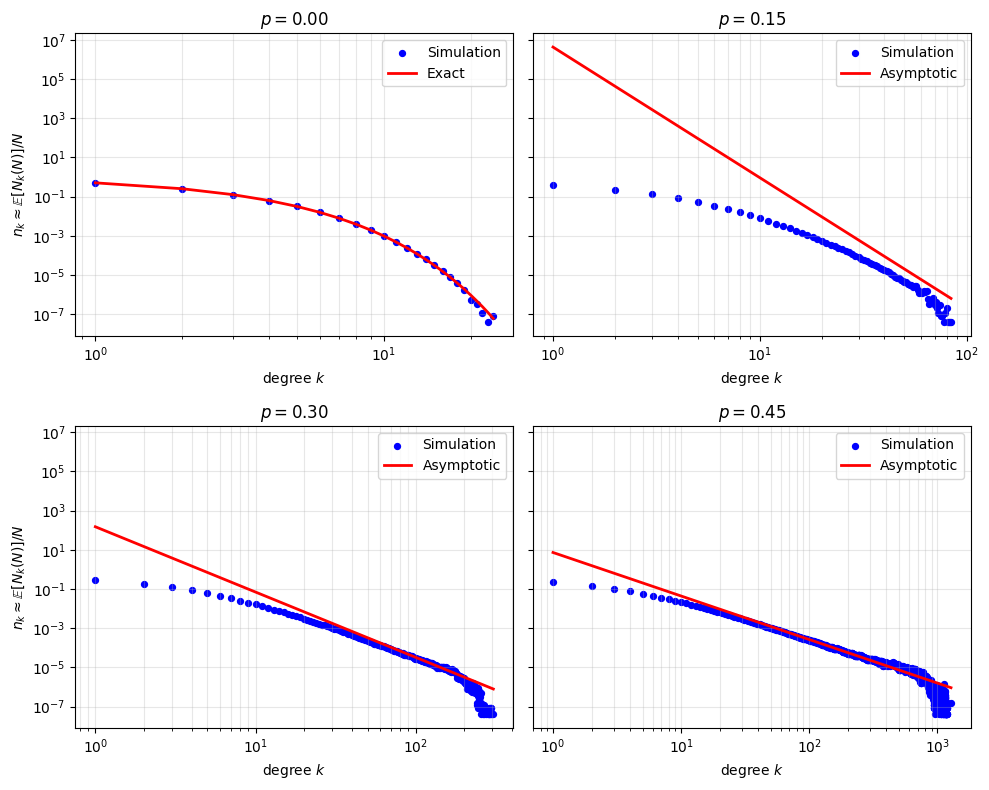

In [15]:
p_list = [0.0, 0.15, 0.30, 0.45]

# plot empirical degree distributions against theory
plot_sparse_degree_distribution(
    p_list=p_list,
    N=100000,
    num_runs=250,
    seed=12345
)

plt.show()

### Number of Triangles and Clustering Coefficient

In our report, we obtained that the number of triangles is

\begin{equation*}
    t_N = \begin{cases}
       2N(H_N - 1) + 6(\Phi_{2/3}(N) - N) & \text{if } p = \frac{1}{3}\\
       4\Phi_{3/2}(N) - 2N(H_N - 1) & \text{if } p = \frac{1}{2}\\
      \frac{2}{(1-2p)(1-3p)}N + \frac{2}{1-2p}\Phi_{2p}(N) - \frac{2}{1-3p} \Phi_{3p}(N)  & \text{if } p \neq \frac{1}{2},\frac{1}{3}\\
    \end{cases}
\end{equation*}

and the global clustering coefficient is approximately $\frac{3p}{1+2p}$.

We provide numerical evidence supporting these conclusions using the code below.

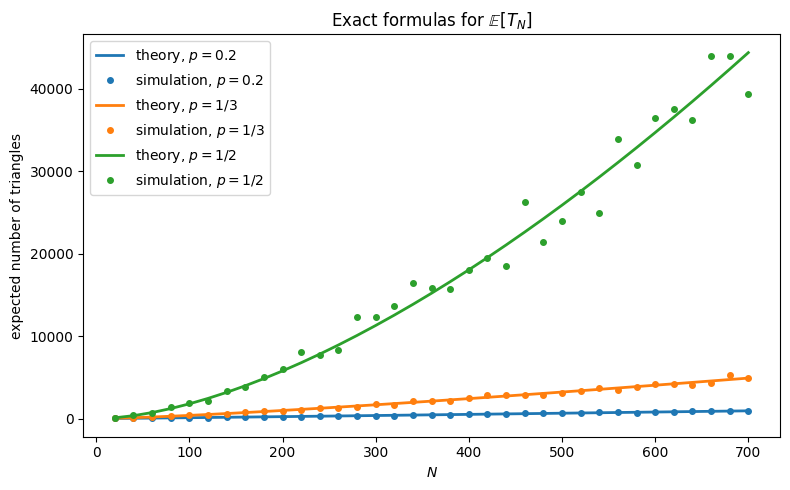

In [16]:
import math
import numpy as np
import matplotlib.pyplot as plt

def phi(a, N): # computes Phi_a(N) = Gamma(N+a) / (Gamma(N) Gamma(1+a))
    N = np.asarray(N, dtype=int)
    return np.array([np.exp(math.lgamma(n + a) - math.lgamma(n) - math.lgamma(1 + a)) for n in N])

def simulate_one_run_triangles(N, p, rng):
    if N < 1:
      raise ValueError("N must be at least 1")
    if N == 1:
      return 0
    if p < 0 or p > 1:
      raise ValueError("p must be between 0 and 1")

    adjacency = [set() for _ in range(N)]  #adjacency[i] is set of neighbours of node i
    T = 0  # number of triangles
    W = 0  # number of wedges
    for new_node in range(1,N):# existing nodes at step t are 0, 1, ..., t-1
        target_node = int(rng.integers(new_node))   # choose target uniformly
        target_neighbours = list(adjacency[target_node]) # looks at neighbours before attaching new node
        deg_target = len(target_neighbours)

        if rng.random() < p:
            nbr_set = set(target_neighbours) # copy all neighbours of target
            edges_among_nbrs = sum(len(adjacency[v] & nbr_set) for v in target_neighbours) // 2 # count edges already present among neighbours of u
            T += deg_target + edges_among_nbrs # new triangles created by new node
            W += deg_target + sum(len(adjacency[v]) for v in target_neighbours) + deg_target * (deg_target + 1) // 2 # update wedge count
            attach_to = [target_node] + target_neighbours
        else:
            W += deg_target #only target gets one extra neighbour
            attach_to = [target_node]

        for v in attach_to: # add new node and all its edges
            adjacency[new_node].add(v)
            adjacency[v].add(new_node)

    return T, W

def harmonic_numbers(N): #computes first N harmonic numbers
    N = np.asarray(N, dtype=int)
    return np.array([np.sum(1.0 / np.arange(1, n + 1)) for n in N])

def expected_triangles_exact(N, p):
    N = np.asarray(N, dtype=int)

    if np.isclose(p, 1/3): # if p = 1/3
        H = harmonic_numbers(N)
        return 2 * N * (H - 1) + 6 * (phi(2/3, N) - N)

    elif np.isclose(p, 1/2): #if p = 1/2
        H = harmonic_numbers(N)
        return 4 * phi(3/2, N) - 2 * N * (H + 1)

    else: # if p !=  1/2, 1/3
        return ((2 * p / ((1 - 2 * p) * (1 - 3 * p))) * N + (2 / (1 - 2 * p)) * phi(2 * p, N) - (2 / (1 - 3 * p)) * phi(3 * p, N))

p_cases = [0.2, 1/3, 1/2]
labels = [r"$p=0.2$", r"$p=1/3$", r"$p=1/2$"]
N_values = np.arange(20, 701, 20)   # values of N to test
runs = 100                          # Monte Carlo runs per N
rng = np.random.default_rng(12345)
plt.figure(figsize=(8, 5))

for p, label in zip(p_cases, labels):
    sim_means = []
    for N in N_values:
        triangles = []
        for _ in range(runs):
            T, W = simulate_one_run_triangles(N, p, rng)
            triangles.append(T)
        sim_means.append(np.mean(triangles))
    theory = expected_triangles_exact(N_values, p)
    line, = plt.plot(N_values, theory, linewidth=2, label=f"theory, {label}")
    plt.plot(N_values, sim_means, "o", color=line.get_color(), ms=4,
             label=f"simulation, {label}")

plt.xlabel(r"$N$")
plt.ylabel(r"expected number of triangles")
plt.title(r"Exact formulas for $\mathbb{E}[T_N]$")
plt.legend()
plt.tight_layout()
plt.show()

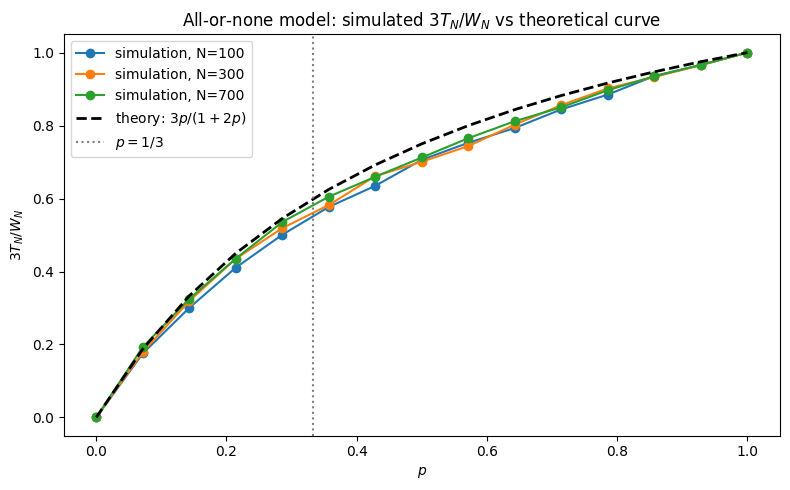

In [17]:
import math
import numpy as np
import matplotlib.pyplot as plt

def simulate_one_run_tw(N,p,rng):
  if N < 1:
    raise ValueError("N must be at least 1")
  if N == 1:
    return 0
  if p < 0 or p > 1:
    raise ValueError("p must be between 0 and 1")
  adjacency = [set() for _ in range(N)] # adjacency[i] is set of neighbours of node i
  T = 0           # number of triangles
  W = 0           # number of wedges

  for new_node in range(1,N): # existing nodes at step t are 0, 1, ..., t-1
    target_node = rng.integers(new_node)  # choose target uniformly
    target_neighbours = list(adjacency[target_node]) # looks at neighbours before attaching new node
    deg_target = len(target_neighbours)

    if rng.random() < p: # with probability p, copy all neighbours of the target
      nbr_set = set(target_neighbours) # copy all neighbours of target
      edges_among_nbrs = sum(len(adjacency[v] & nbr_set) for v in target_neighbours) // 2 # count edges already present among neighbours of u
      T += deg_target + edges_among_nbrs # new triangles created by new node
      W += deg_target + sum(len(adjacency[v]) for v in target_neighbours) + deg_target * (deg_target + 1) // 2 # update wedge count
      attach_to = [target_node] + target_neighbours
    else:
      W += deg_target #only target gets one extra neighbour
      attach_to = [target_node]

    for v in attach_to:
      adjacency[new_node].add(v)
      adjacency[v].add(new_node)
  return T, W

N_values = [100, 300, 700]
p_values = np.linspace(0, 1, 15)
runs = 80
rng = np.random.default_rng(12345)

mean_ratio = {N: [] for N in N_values} # simulate mean value

for N in N_values:
    for p in p_values:
        ratios = []

        for _ in range(runs):
            T, W = simulate_one_run_tw(N, p, rng)
            ratios.append(0.0 if W == 0 else 3 * T / W)

        mean_ratio[N].append(np.mean(ratios))

theory = 3 * p_values / (1 + 2 * p_values) # theoretical curve made

plt.figure(figsize=(8, 5))

for N in N_values:
    plt.plot(p_values, mean_ratio[N], "o-", label=f"simulation, N={N}")

plt.plot(p_values, theory, "k--", linewidth=2, label=r"theory: $3p/(1+2p)$")
plt.axvline(1/3, linestyle=":", color="gray", label=r"$p=1/3$")

plt.xlabel(r"$p$")
plt.ylabel(r"$3T_N/W_N$")
plt.title(r"All-or-none model: simulated $3T_N/W_N$ vs theoretical curve")
plt.legend()
plt.tight_layout()
plt.show()

### Associativity Coefficient

In our report, we consider the associativity coefficient from degrees,

\begin{equation*}
    r =\frac{\sum_{i,j}\big(A_{ij} - \frac{k_ik_j}{2m}\big) k_ik_j}{\sum_{i,j}\big(k_i \delta_{i,j} - \frac{k_ik_j}{2m}\big) k_ik_j} = \frac{Z_N - \frac{X_N^2}{2m}}{Y_N - \frac{X_N^2}{2m}}.
\end{equation*}

Though we could not derive an exact or asympotic


We provide numerical evidence supporting this conclusion using the code below.

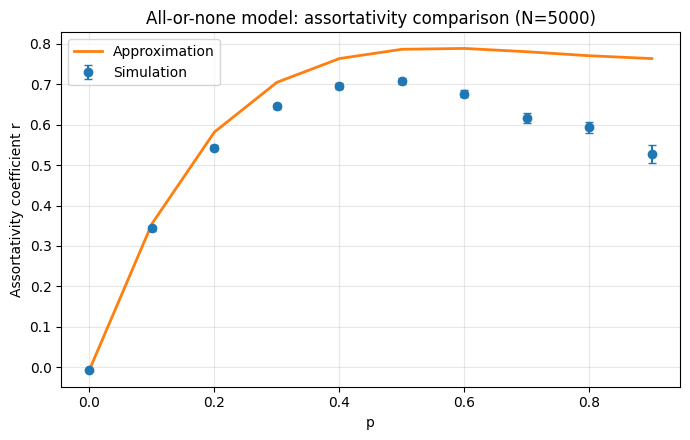

In [10]:
import numpy as np
import matplotlib.pyplot as plt

def simulate_one_run_associativity(N,p,rng):
  if N < 1:
    raise ValueError("N must be at least 1")
  if N == 1:
    return 0
  if p < 0 or p > 1:
    raise ValueError("p must be between 0 and 1")
  adjacency = [set() for _ in range(N)] # adjacency[i] is set of neighbours of node i

  for new_node in range(1,N): # existing nodes at step t are 0, 1, ..., t-1
    target_node = rng.integers(new_node)  # choose target uniformly
    target_neighbours = list(adjacency[target_node]) # looks at neighbours before attaching new node
    adjacency[new_node].add(target_node) # adds target node to new node as edge
    adjacency[target_node].add(new_node) # adds new node to target node as edge
    if rng.random() < p: # with probability p, copy all neighbours of the target
      for neighbour in target_neighbours:
        adjacency[new_node].add(neighbour)
        adjacency[neighbour].add(new_node)

  return adjacency


def assortativity_from_graph(adj): # compute assortativity directly from graph
    degrees = np.array([len(neigh) for neigh in adj], dtype=float)
    l = degrees.sum() / 2.0 #l = number of edges

    if l == 0:
        return np.nan

    X = np.sum(degrees**2) #X = sum_i k_i^2
    Y = np.sum(degrees**3) #Y = sum_i k_i^3

    # Z = sum_{i,j} A_ij k_i k_j = 2 * sum_{edges {i,j}} k_i k_j
    Z = 0.0
    for i, neigh in enumerate(adj):
        ki = degrees[i]
        for j in neigh:
            if j > i:
                Z += 2.0 * ki * degrees[j]

    correction = X**2 / (2.0 * l)
    denom = Y - correction

    return (Z - correction) / denom



def moment_recurrence_predictor(N, p):
    # Initial state at N = 1
    l = 0.0  # E[L_1]
    x = 0.0  # E[X_1]
    t = 0.0  # E[T_1]
    y = 0.0  # E[Y_1]
    z = 0.0  # E[Z_1]

    # update from n nodes to n+1 nodes
    for n in range(1, N):
        l_new = l + 1.0 + (2.0 * p / n) * l
        x_new = x + 2.0 + ((4.0 + 6.0 * p) / n) * l + (3.0 * p / n) * x
        t_new = t + (2.0 * p / n) * l + (3.0 * p / n) * t
        y_new = (y + 2.0+ ((6.0 + 8.0*p)/ n)*l + ((3.0 + 6.0*p) / n)*x + (4.0 *p/ n)*y)
        z_new = (z + 2.0 + ((4.0 + 12.0*p) / n)*l + ((2.0 + 6.0*p)/n)*x+ (6.0*p/n)*t+ (4.0 *p/n)*z)
        l, x, t, y, z = l_new, x_new, t_new, y_new, z_new

    correction = x**2 / (2.0 * l)
    denom = y - correction

    r_theory = (z - correction) / denom

    return r_theory



def compare_assortativity(N=800, trials=200, seed=0):
    rng = np.random.default_rng(seed)

    p_values = np.linspace(0.0, 0.9, 10) # p-values to test

    sim_mean = []
    sim_se = []      # standard error of the mean
    theory = []

    for p in p_values:
        theory.append(moment_recurrence_predictor(N, p)) # from exact recurrences
        r_vals = [] # from simulation
        for _ in range(trials):
            adj = simulate_one_run_associativity(N, p, rng)
            r_vals.append(assortativity_from_graph(adj))

        r_vals = np.array(r_vals, dtype=float)
        sim_mean.append(np.nanmean(r_vals))
        sim_se.append(np.nanstd(r_vals, ddof=1) / np.sqrt(trials))

    sim_mean = np.array(sim_mean)
    sim_se = np.array(sim_se)
    theory = np.array(theory)

    # plot
    plt.figure(figsize=(7, 4.5))
    plt.errorbar(
        p_values, sim_mean, yerr=sim_se, fmt='o',
        capsize=3, label='Simulation'
    )
    plt.plot(p_values, theory, '-', linewidth=2, label='Approximation')

    plt.xlabel('p')
    plt.ylabel('Assortativity coefficient r')
    plt.title(f'All-or-none model: assortativity comparison (N={N})')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


# Run the comparison
compare_assortativity(N=5000, trials=100, seed=1)

### Average Shortest-Path Distance

In our report, we obtain the following exact expression for the expected average shortest-path distance between pairs of nodes $A_N$ in the *all-or-none* model:

\begin{equation*}
\mathbb{E}[A_N] = \frac{2(N+1)}{N-1}\bigg[(1-p)H_N - 2 + \frac{5p}{2}  + \frac{2-3p}{N+1}\bigg].
\end{equation*}

We provide numerical evidence supporting this conclusion using the code below.

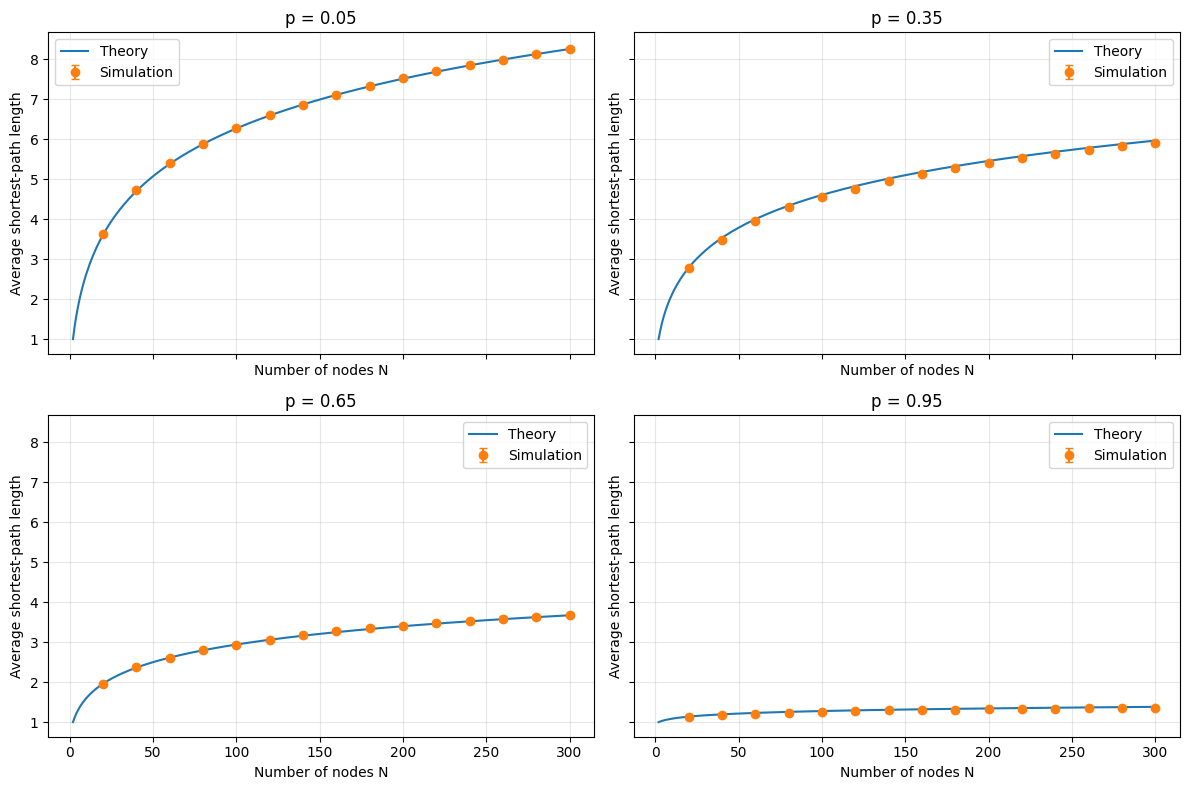

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

def harmonic_numbers_up_to(n_max): # returns list of first n harmonic numbers
    H = np.zeros(n_max + 1, dtype=float)
    H[1:] = np.cumsum(1.0 / np.arange(1, n_max + 1))
    return H

def theory_average_distance(N, p, H=None): # theoretical average shortest-path distance
    N = np.asarray(N, dtype=int)
    if H is None:
        H = harmonic_numbers_up_to(int(np.max(N)))
    HN = H[N]
    return (2.0 * (N + 1) / (N - 1)) * ((1 - p) * HN - 2 + 2.5 * p + (2 - 3 * p) / (N + 1))

def simulate_one_run_graph(N,p,checkpoints, rng):
  if N < 1:
    raise ValueError("N must be at least 1")
  if N == 1:
    return 0
  if p < 0 or p > 1:
    raise ValueError("p must be between 0 and 1")
  adjacency = [set() for _ in range(N)] # adjacency[i] is set of neighbours of node i
  checkpoints = set(checkpoints)
  values = {}

  for new_node in range(1,N): # existing nodes at step t are 0, 1, ..., t-1
    target_node = rng.integers(new_node)  # choose target uniformly
    target_neighbours = list(adjacency[target_node]) # looks at neighbours before attaching new node
    adjacency[new_node].add(target_node) # adds target node to new node as edge
    adjacency[target_node].add(new_node) # adds new node to target node as edge
    if rng.random() < p: # with probability p, copy all neighbours of the target
      for neighbour in target_neighbours:
        adjacency[new_node].add(neighbour)
        adjacency[neighbour].add(new_node)
    current_N = new_node + 1
    if current_N in checkpoints: # record average shortest-path length when required
      G = nx.Graph()
      G.add_nodes_from(range(current_N))
      for u in range(current_N):
        for v in adjacency[u]:
          if u < v: # add undirected edge once
            G.add_edge(u, v)
      values[current_N] = nx.average_shortest_path_length(G)

  return values

def simulate_mean_distances(N_values, p, runs=50, seed=12345):
    rng = np.random.default_rng(seed)
    N_values = np.array(sorted(N_values), dtype=int)
    max_N = int(np.max(N_values))

    samples = np.zeros((runs, len(N_values)), dtype=float)

    for r in range(runs):
        vals = simulate_one_run_graph(max_N, p=p, checkpoints=N_values, rng=rng)
        samples[r, :] = [vals[N] for N in N_values]

    mean = samples.mean(axis=0)
    stderr = samples.std(axis=0, ddof=1) / np.sqrt(runs)
    return mean, stderr
p_values = [0.05, 0.35, 0.65, 0.95]   # four values of p to test
N_values = np.arange(20, 301, 20) # simulation checkpoints
runs = 100 # increase for smoother averages
H = harmonic_numbers_up_to(int(np.max(N_values)))
N_dense = np.arange(2, int(np.max(N_values)) + 1)
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True, sharey=True)
axes = axes.ravel()

for ax, p in zip(axes, p_values):
    theory_dense = theory_average_distance(N_dense, p, H=harmonic_numbers_up_to(int(np.max(N_dense))))
    theory_pts = theory_average_distance(N_values, p, H=H)
    sim_mean, sim_stderr = simulate_mean_distances(N_values, p, runs=runs, seed=12345 + int(1000 * p))

    ax.plot(N_dense, theory_dense, label="Theory")
    ax.errorbar(N_values, sim_mean, yerr=sim_stderr, fmt="o", capsize=3, label="Simulation")

    ax.set_title(f"p = {p}")
    ax.set_xlabel("Number of nodes N")
    ax.set_ylabel("Average shortest-path length")
    ax.grid(alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.show()